# WhyWatt — Rate Projection Review

Offline comparison of WhyWatt's projected retail rates against three independent institutional
projections (**US EIA**, **CEC 2025 IEPR**, **E3 2020**), per fuel. **Reported in real 2024$**
(the CEC basis) with a nominal toggle — set `BASIS` in the setup cell.

- **Build plan:** `docs/OfflineRateProjection_Plan.md`
- **Methodology (math):** `docs/Energy_Rate_Projection_Spec.md`
- **Plain-language guide:** `docs/help/rate_projection_guide.md`
- **Gas source verification / provenance:** `docs/rate_projection_gas_provenance.md`

Nothing here is imported by the live WhyWatt sim (the sim consumes the exported
`whywatt_rate_projection.json` bundle). All inputs are in `data/rates/projection/`
(CEC IEPR + 2024 CPUC ACC) with provenance + sha256.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Repo root: this notebook lives in notebooks/, so parent is the repo.
ROOT = Path.cwd() if (Path.cwd()/ "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from rate_projection import ProjectedRateModel, SCENARIO_PRESETS

PROJ = ROOT / "data" / "rates" / "projection"
BENCH = PROJ / "benchmarks"

# ── Reporting basis: 'real' (2024$, matches CEC Figure 8) or 'nominal'. Flip and re-run. ──
BASIS = "real"          # 'real' | 'nominal'
REAL_BASE = 2024        # CEC Figure 8 is in 2024 dollars

m = ProjectedRateModel(data_dir=str(PROJ), base_year=2025, horizon_end=2050)
YEARS = m.years

def _real2024_to_nominal(series):
    d0 = m._deflator[REAL_BASE]
    return {y: v * m._deflator[y] / d0 for y, v in series.items() if y in m._deflator}

def to_basis(series, native="nominal"):
    "Normalize a series to the chosen BASIS. `native` = 'nominal' or 'real_2024'."
    if BASIS == "nominal":
        return _real2024_to_nominal(series) if native == "real_2024" else dict(series)
    # BASIS == 'real'
    return dict(series) if native == "real_2024" else m.to_real(series, base_year=REAL_BASE)

def anchors_to_path(anchors, years=YEARS):
    "Log-linear interpolate {year: value} anchor points across `years` (compounding look)."
    ax = sorted(int(y) for y in anchors)
    ay = [float(anchors[str(y)] if str(y) in anchors else anchors[y]) for y in ax]
    xs = np.array(ax, float); ys = np.log(np.array(ay, float))
    return {y: float(np.exp(np.interp(y, xs, ys))) for y in years}

SCEN_COLORS = {"conservative": "#2c7fb8", "moderate": "#d95f0e", "stress": "#7a0177"}
print("Basis:", BASIS, "| base residual  elec $%.3f/kWh  gas $%.3f/therm"
      % (m.residual_base('elec'), m.residual_base('gas')))

Basis: real | base residual  elec $0.297/kWh  gas $1.123/therm


## 1 · Our scenarios vs. the institutional benchmarks

The headline: where WhyWatt's `conservative / moderate / stress` retail curves sit relative to the
floor (EIA) and the death-spiral benchmarks (E3, CEC). Left = electricity, right = gas.
The scenario presets are **provisional v1** residual-growth assumptions — this chart is how we
calibrate them.

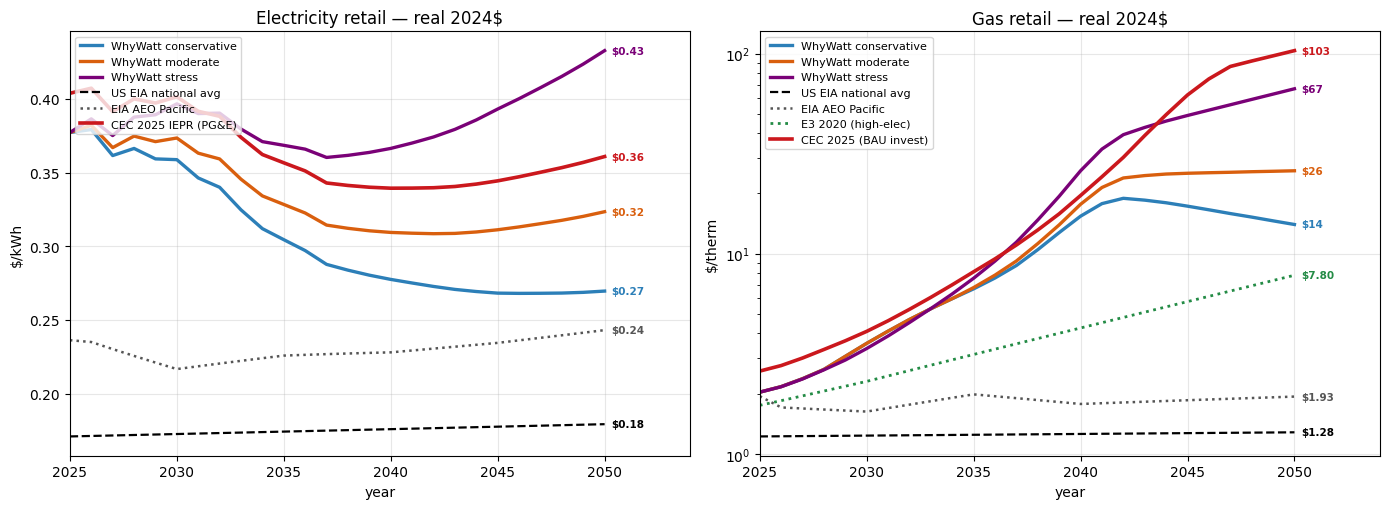

Electric moderate vs CEC (real 2024$, cents/kWh):
  2025: ours 37.7   CEC ~40
  2030: ours 37.3   CEC ~40
  2040: ours 30.9   CEC ~34
  2050: ours 32.3   CEC ~36


In [2]:
eia    = json.loads((BENCH/"eia_aeo.json").read_text())
e3     = json.loads((BENCH/"e3_pathways_2020.json").read_text())
cecg   = json.loads((BENCH/"cec_2025_iepr_gas.json").read_text())
cece   = json.loads((BENCH/"cec_2025_iepr_electric.json").read_text())

# Per-fuel curve specs put on the chosen BASIS: (label, series, color, linestyle, linewidth).
# WhyWatt retail + EIA/E3 are native nominal; the CEC benchmarks are native real 2024$.
# CEC lines are SOLID (distinct within a panel); every line gets a right-edge endpoint label
# because the log y-axis makes exact levels hard to read.
def _curves(fuel):
    fk = "electric" if fuel == "elec" else "gas"
    rows = [
        (f"WhyWatt conservative", to_basis(m.retail(fuel, "conservative")), SCEN_COLORS["conservative"], "-",  2.4),
        (f"WhyWatt moderate",     to_basis(m.retail(fuel, "moderate")),     SCEN_COLORS["moderate"],     "-",  2.4),
        (f"WhyWatt stress",       to_basis(m.retail(fuel, "stress")),       SCEN_COLORS["stress"],       "-",  2.4),
        ("US EIA national avg",   to_basis(anchors_to_path(eia[fk]["series"])),                      "black",   "--", 1.6),
        ("EIA AEO Pacific",       to_basis(anchors_to_path(eia["pacific_aeo2026"][fk]["series"])),   "#555555", ":",  1.8),
    ]
    if fuel == "elec":
        rows.append(("CEC 2025 IEPR (PG&E)", to_basis(anchors_to_path(cece["electric"]["series_real_2024"]), native="real_2024"), "#cb181d", "-", 2.6))
    else:
        rows.append(("E3 2020 (high-elec)",   to_basis(anchors_to_path(e3["gas"]["nominal_therm_approx"])),                "#238b45", ":", 2.0))
        rows.append(("CEC 2025 (BAU invest)", to_basis(anchors_to_path(cecg["gas"]["series"]), native="real_2024"),       "#cb181d", "-", 2.6))
    return rows

def _fmt(v):
    return f"${v:,.2f}" if v < 10 else f"${v:,.0f}"

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
xmax = max(YEARS)
for ax, fuel, unit in [(axes[0], "elec", "$/kWh"), (axes[1], "gas", "$/therm")]:
    for label, s, color, ls, lw in _curves(fuel):
        ax.plot(list(s), list(s.values()), color=color, ls=ls, lw=lw, label=label)
        ax.annotate(_fmt(s[xmax]), xy=(xmax, s[xmax]), xytext=(5, 0),
                    textcoords="offset points", va="center", ha="left",
                    fontsize=7.5, fontweight="bold", color=color)
    ax.set_title(f"{'Electricity' if fuel=='elec' else 'Gas'} retail — {BASIS} 2024$")
    ax.set_xlabel("year"); ax.set_ylabel(unit); ax.grid(alpha=.3); ax.legend(fontsize=8, loc="upper left")
    ax.set_xlim(2025, xmax + (xmax - 2025) * 0.16)   # headroom for the endpoint labels
axes[1].set_yscale("log")  # gas spans floor->CEC over ~1.5 orders of magnitude
plt.tight_layout(); plt.show()
print("Electric moderate vs CEC (real 2024$, cents/kWh):")
em = to_basis(m.retail("elec","moderate"))
for y in [2025,2030,2040,2050]:
    print(f"  {y}: ours {em[y]*100:.1f}   CEC ~{anchors_to_path(cece['electric']['series_real_2024'])[y]*100:.0f}")

## 1b · Why electricity stays flat but gas spirals — Revenue Requirement ÷ Sales

The residual grows as `RR(y) / Sales(y)` (methodology §5.2). The rate outcome is decided by the
*denominator*: electricity **sales grow** (electrification adds kWh), offsetting rising revenue
requirements → real-flat. Gas **sales fall** (customers leave) → the same fixed cost lands on
fewer therms → spiral. Same equation, opposite denominators. (CEC 2025 IEPR: "~2.5%/yr sales
growth offsets continued growth in revenue requirements.")

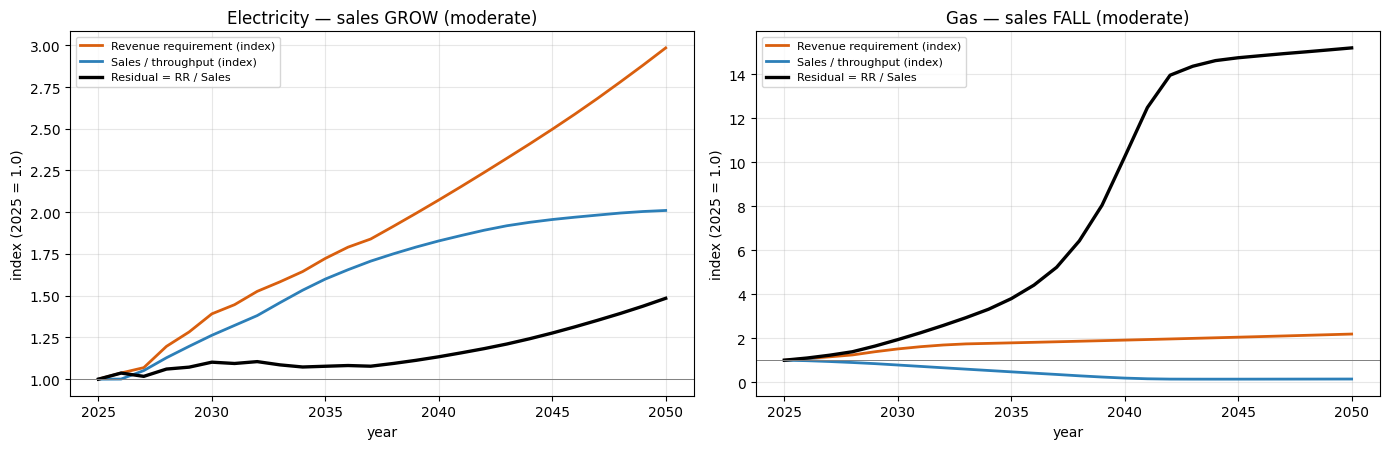

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, fuel in [(axes[0], "elec"), (axes[1], "gas")]:
    rr = m.rr_index(fuel, "moderate"); sa = m.sales_index(fuel, "moderate")
    res = {y: rr[y]/sa[y] for y in rr}
    ax.plot(list(rr), list(rr.values()), color="#d95f0e", lw=2, label="Revenue requirement (index)")
    ax.plot(list(sa), list(sa.values()), color="#2c7fb8", lw=2, label="Sales / throughput (index)")
    ax.plot(list(res), list(res.values()), color="#000000", lw=2.4, label="Residual = RR / Sales")
    ax.axhline(1.0, color="grey", lw=.7)
    ax.set_title(f"{'Electricity — sales GROW' if fuel=='elec' else 'Gas — sales FALL'} (moderate)")
    ax.set_xlabel("year"); ax.set_ylabel("index (2025 = 1.0)"); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2 · Why retail rises — `mc + residual` decomposition

The marginal *bill* cost (`mc`, from the ACC) is nearly flat; the **residual** is both the majority
of the bill and the part that grows. This is the structural reason a single CAGR misleads.

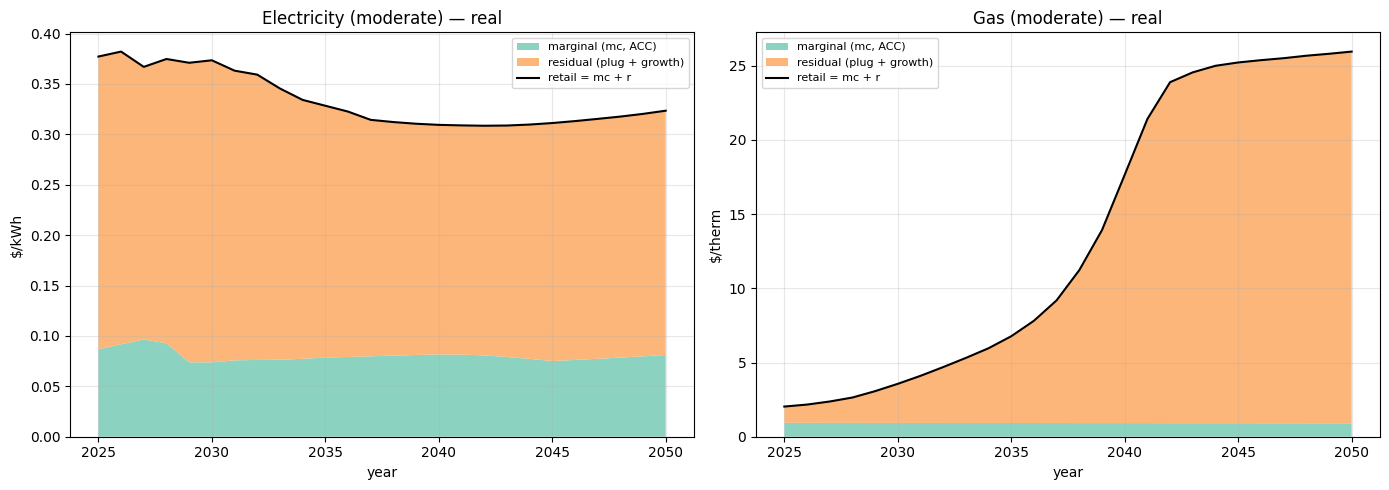

mc share of retail @2050 (moderate):
  elec: mc $0.144 / retail $0.573 = 25%
  gas: mc $1.602 / retail $45.964 = 3%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fuel, unit in [(axes[0], "elec", "$/kWh"), (axes[1], "gas", "$/therm")]:
    d = m.decompose(fuel, "moderate")
    yrs = list(d)
    mc = to_basis({y: d[y]["mc"] for y in yrs})
    rr = to_basis({y: d[y]["residual"] for y in yrs})
    ax.stackplot(yrs, list(mc.values()), list(rr.values()),
                 labels=["marginal (mc, ACC)", "residual (plug + growth)"],
                 colors=["#7fcdbb", "#fdae6b"], alpha=.9)
    tot = to_basis(m.retail(fuel, "moderate"))
    ax.plot(list(tot), list(tot.values()), "k", lw=1.5, label="retail = mc + r")
    ax.set_title(f"{'Electricity' if fuel=='elec' else 'Gas'} (moderate) — {BASIS}")
    ax.set_xlabel("year"); ax.set_ylabel(unit); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("mc share of retail @2050 (moderate):")
for fuel in ["elec","gas"]:
    d=m.decompose(fuel,"moderate")[2050]
    print(f"  {fuel}: mc ${d['mc']:.3f} / retail ${d['retail']:.3f} = {100*d['mc']/d['retail']:.0f}%")

## 3 · The gas death-spiral, benchmarked

How far the *gas* rate could climb by 2050 depends almost entirely on whether the gas system keeps
investing as customers leave. The 7× gap between E3 (managed) and CEC (business-as-usual) is a
policy choice, not physics.

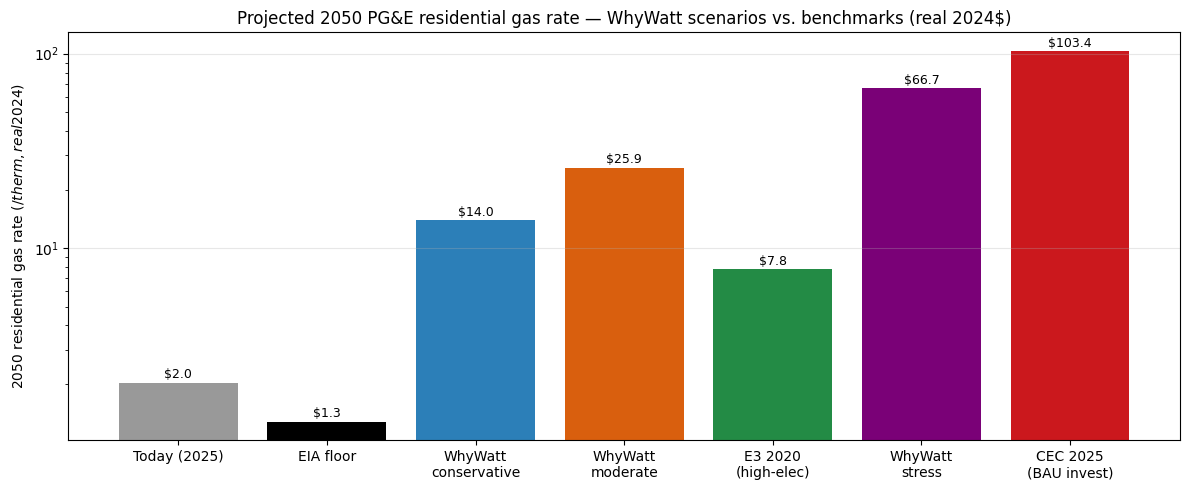

In [5]:
# Every bar is put on the chosen BASIS (real 2024$ by default). WhyWatt retail and the EIA/E3
# series are native nominal; the CEC 2025 gas benchmark (tn=264063) is native real 2024$.
def _at(series, year=2050, native="nominal"):
    return to_basis(series, native)[year]

labels, vals = [], []
labels.append("Today (2025)");           vals.append(to_basis(m.retail("gas","moderate"))[2025])
labels.append("EIA floor");              vals.append(_at(anchors_to_path(eia["gas"]["series"])))
labels.append("WhyWatt\nconservative");  vals.append(_at(m.retail("gas","conservative")))
labels.append("WhyWatt\nmoderate");      vals.append(_at(m.retail("gas","moderate")))
labels.append("E3 2020\n(high-elec)");   vals.append(_at(anchors_to_path(e3["gas"]["nominal_therm_approx"])))
labels.append("WhyWatt\nstress");        vals.append(_at(m.retail("gas","stress")))
labels.append("CEC 2025\n(BAU invest)"); vals.append(_at(anchors_to_path(cecg["gas"]["series"]), native="real_2024"))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#999999","#000000","#2c7fb8","#d95f0e","#238b45","#7a0177","#cb181d"]
bars = ax.bar(labels, vals, color=colors)
ax.set_yscale("log"); ax.set_ylabel(f"2050 residential gas rate ($/therm, {BASIS} 2024$)")
ax.set_title(f"Projected 2050 PG&E residential gas rate — WhyWatt scenarios vs. benchmarks ({BASIS} 2024$)")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v*1.05, f"${v:,.1f}", ha="center", fontsize=9)
ax.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()

## 4 · Electricity social overlay (context)

The ACC's rising **damage carbon** for electricity — deliberately kept *out* of the bill (§R6 of the
guide) and shown here only as context. It climbs with the social cost of carbon while the electric
*bill* marginal stays flat. (Gas social overlay awaits the external SCC harvest.)

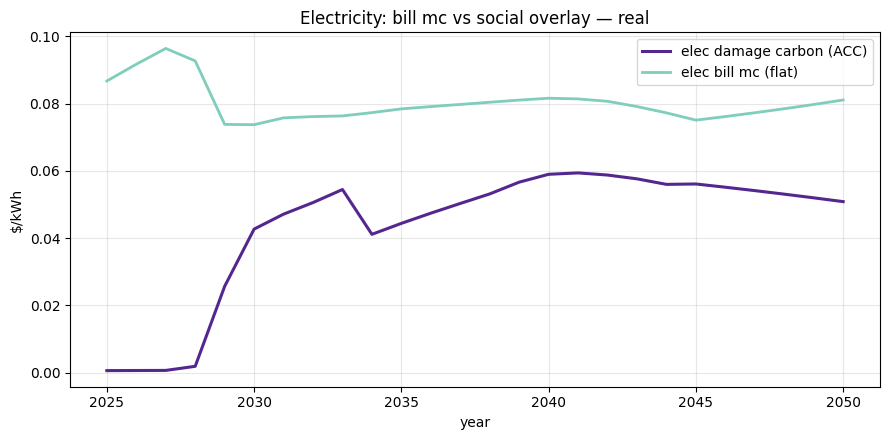

In [6]:
soc = m.social_elec()
if soc:
    s = to_basis(soc)
    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.plot(list(s), list(s.values()), color="#54278f", lw=2.2, label="elec damage carbon (ACC)")
    billmc = to_basis(m.mc("elec"))
    ax.plot(list(billmc), list(billmc.values()), color="#7fcdbb", lw=2.0, label="elec bill mc (flat)")
    ax.set_xlabel("year"); ax.set_ylabel("$/kWh"); ax.set_title(f"Electricity: bill mc vs social overlay — {BASIS}")
    ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()
else:
    print("No electric social series loaded.")

## Caveats & TODOs

- **Basis is real 2024$ (2026-09-09 correction).** All CEC anchors are published in real 2024$
  (electric tn=268239; gas tn=264063 — its 'Commodity Prices' sheet is headed "2024$/Therm"). The
  model computes in nominal (mc + residual, both nominal) and `to_real(base_year=2024)` reports it;
  the CEC gas benchmark carries `native="real_2024"`. Previously the gas delivered price was indexed
  as if nominal, so the `real` view double-deflated gas — now fixed. See
  `docs/rate_projection_gas_provenance.md`. The **>$20/therm** gas figures are correct in real 2024$:
  they come from the CEC Planning-Area-demand × front-load/flat-recovery death-spiral cases, not the
  CEC central demand baseline (tn=269887, ~$8.6/therm real 2024$ by 2045).
- **Residual uses `RR(y) / Sales(y)`** (methodology §5.2). Electric `moderate` tracks the CEC 2025
  IEPR PG&E real-flat line; gas keeps the spiral (falling denominator).
- **RR and Sales growths are still provisional presets**, not yet a bucket-level `RR` (wildfire,
  T&D…) or the harvested CEC CED 2025 `Sales(y)` curve — those are the next refinement.
- **"EIA inflation-only" is a reference line, not a floor for electricity.** CA electric rates are
  projected real-flat-to-declining (sales growth), so the CA-authority line (CEC) sits *below*
  inflation-only for electricity.
- **Gas social overlay** needs the external SCC(y) path (EPA) + the ACC gas emission/methane params
  already in `acc_marginal_gas.json`.
- **E3 real→nominal** uses the CEC deflator from a 2020 base; treat E3's line as approximate.